In [13]:
import findiff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1D diffusion equation
$$
\frac{\partial{q}}{\partial{t}} = \sigma\frac{\partial^2q}{\partial{x^2}}
$$

In [85]:
def plot_heatmap(evolutions, xs, title=""):
    fig, ax = plt.subplots(1, 1, figsize=(18,6))
    
    cax = plt.imshow(
        evolutions,
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[xs[0], xs[-1], 0, len(evolutions) - 1],
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("Time Steps")
    fig.colorbar(cax, ax=ax, label="C(x,t)")


In [100]:
def gaussian_plume(x, mean=0.1, sigma=0.05):
    return np.exp(-((x - mean) ** 2) / (2 * sigma**2))

def evolve(func, xs, ts, D, f0):
    T = f0(xs)
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]

    results = [T.copy()]

    for _ in ts[:-1]:
        Tprim = func(T, dt, dx, D)
        results.append(Tprim.copy())
        T = np.copy(Tprim)

    return np.array(results)

# C - concentration
# dt, dx - changes
# D - diffusion coefficient
# Dirichlet boundary
def diffusion_dirichlet(C, dt, dx, D):
    C_new = C.copy()

    C_new[1:-1] = C[1:-1] + dt*D/(dx**2) * (C[:-2] - 2 * C[1:-1] + C[2:])

    C_new[0] = 0
    C_new[-1] = 0
    
    return C_new

def diffusion_neumann(C, dt, dx, D):
    C_new = C.copy()

    C_new[1:-1] = C[1:-1] + dt*D/(dx**2) * (C[:-2] - 2 * C[1:-1] + C[2:])

    C_new[0] = C_new[1]
    C_new[-1] = C_new[-2]
    
    return C_new


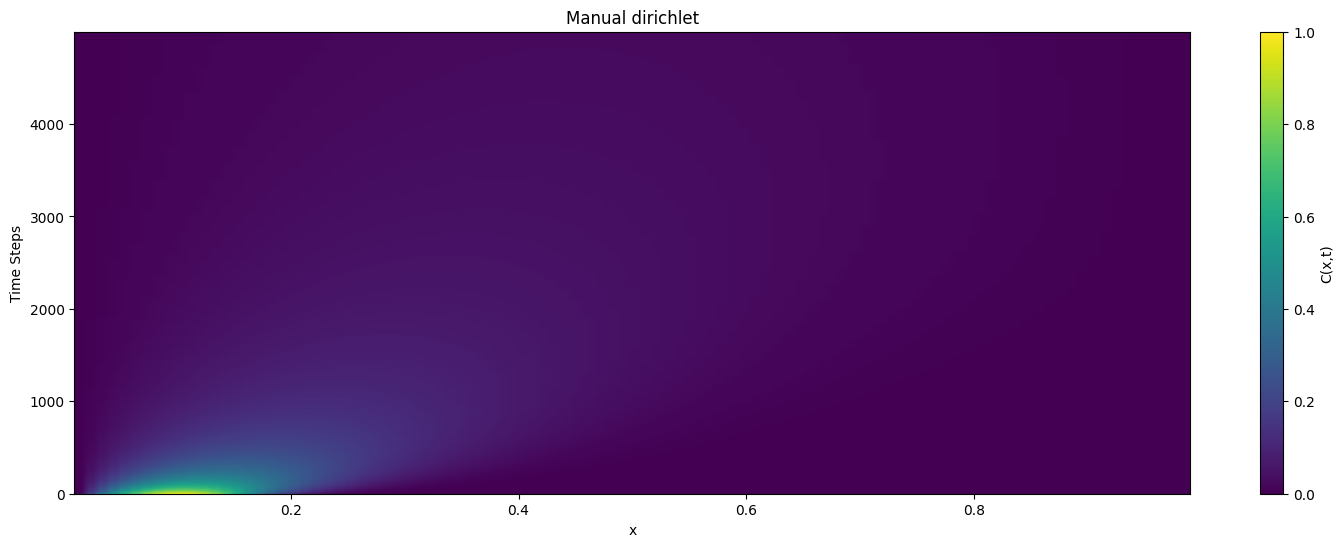

In [99]:
D = 0.01
Nx = 100
Lx = 1
Lt = 10

dx = Lx / Nx
xs = np.arange(dx, Lx, dx)
CFL_coeff = 0.4 # TODO: Research more, Von Neumann analysis???
dt = CFL_coeff * (dx**2) / (2*D)

ts = np.arange(0, Lt, dt)
evolutions = evolve(diffusion_dirichlet, xs, ts, D, gaussian_plume)

plot_heatmap(evolutions, xs, "Manual dirichlet")

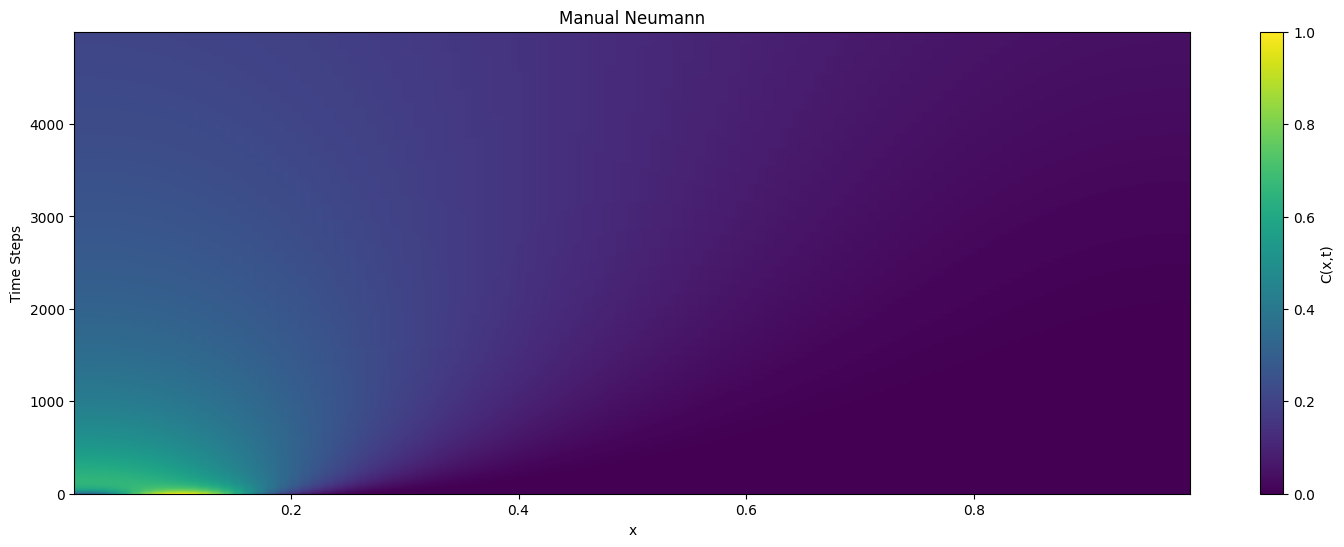

In [102]:
D = 0.01
Nx = 100
Lx = 1
Lt = 10

dx = Lx / Nx
xs = np.arange(dx, Lx, dx)
CFL_coeff = 0.4 # TODO: Research more, Von Neumann analysis???
dt = CFL_coeff * (dx**2) / (2*D)

ts = np.arange(0, Lt, dt)
evolutions = evolve(diffusion_neumann, xs, ts, D, gaussian_plume)

plot_heatmap(evolutions, xs, "Manual Neumann")

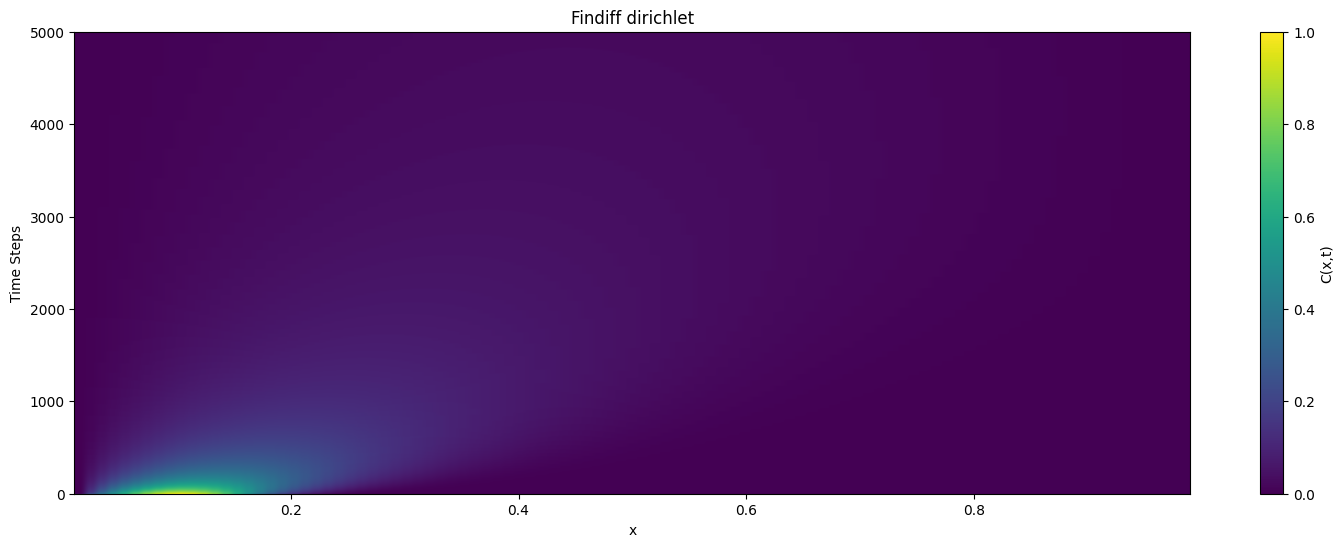

In [98]:
D = 0.01
Nx = 100
Lx = 1
Lt = 10

dx = Lx / Nx
xs = np.arange(dx, Lx, dx)
C = gaussian_plume(xs)
evolutions = [C.copy()]

d2dx2 = findiff.Diff(0, dx, periodic=False)**2
CFL_coeff = 0.4 # TODO: Research more, Von Neumann analysis???
dt = CFL_coeff * (dx**2) / (2*D)
Nt = int(Lt / dt)

def diff_step_dirichlet(C, D, d2dx2):
    C = C + dt * D * d2dx2(C)
    C[0] = 0
    C[-1] = 0

for _ in range(Nt):
    C = C + dt * D * d2dx2(C)
    C[0] = 0
    C[-1] = 0
    evolutions.append(C.copy())

plot_heatmap(evolutions, xs, "Findiff dirichlet")